# Réalisation du plan d'expérience de l'algorithme du Plus Proche Voisin (Nearest Neighbor)

Ce plan d'expérience suivra ce plan : 
- Définition des paramètres globaux
- Étude de trajectoire
- Étude de l'influence des paramètres
- Définition des paramètres optimisés

## Définition des paramètres globaux

Nous allons réaliser l'étude statistique sur les paramètres suivants:
- $N= \{10, 12, 15, 17, 20, 22, 25, 30\}$ : nombre de sommets
- `multi_start` $\in \{\text{True}, \text{False}\}$ : paramètre principal de l'algorithme
  - `True` : l'algorithme est lancé depuis **chaque sommet** du graphe, et le meilleur résultat est conservé
  - `False` : l'algorithme est lancé depuis **un seul sommet aléatoire** sans contrainte de précédence

L'objectif est d'itérer sur les mêmes graphes. Nous utilisons donc des `seed` pour chaque instance de graphe $N$.
Nous allons ensuite calculer la borne de chaque graphe. Cela nous permettra de calculer le `gap` pour comparer équitablement les algorithmes entre eux.

### Résultats

Chaque algorithme doit avoir en sortie: 
- le meilleur coût des itérations
- la moyenne des coûts
- la médiane des coûts
- l'écart-type
- le minimum et le maximum
- graphiques:
    - Trajectoire (accumulation du coût au fil des nœuds visités)
    - Influence de chaque paramètre (Heatmap à double entrée (type github)) → tendance générale
    - Distance à la borne (`gap`)
- Meilleurs paramètres

In [1]:
import sys

import numpy as np
import networkx as nx

sys.path.insert(0, "../")
sys.path.insert(0, "../algorithms/")

from graph_generator import generate_graph

### Paramètres globaux et génération des instances

- `N_VALUES` : tailles de graphe étudiées
- `NB_SEEDS` : nombre d'instances (seed distinct) par taille — pour itérer sur les mêmes graphes
- `MULTI_START_VALUES` : valeurs du paramètre `multi_start` testées

In [2]:
N_VALUES: list[int] = [10, 12, 15, 17, 20, 22, 25, 30]
NB_SEEDS: int = 10
MULTI_START_VALUES: list[bool] = [False, True]


def get_standard_instances(n: int, nb_seeds: int = NB_SEEDS) -> list[tuple[int, nx.Graph]]:
    """Génère `nb_seeds` graphes reproductibles de taille `n`, un par seed."""
    instances: list[tuple[int, nx.Graph]] = []
    for seed in range(nb_seeds):
        np.random.seed(seed)
        graph = generate_graph(n)
        instances.append((seed, graph))
    return instances

### Borne de référence et gap

Borne inférieure « min-sortants » pour toutes les tailles : $\frac{1}{2} \sum_v \min_{u \neq v} w(v,u)$, arêtes interdites ($w = -1$) exclues.

$$\text{gap} = 100 \times \frac{\text{cost} - \text{reference}}{\text{reference}}$$

In [3]:
def lower_bound_min_outgoing(graph: nx.Graph) -> float:
    """Borne inférieure : demi-somme des arêtes sortantes minimales (arêtes interdites exclues)."""
    total: float = 0.0
    for v in graph.nodes():
        min_edge: float = float("inf")
        for u in graph.nodes():
            if u == v:
                continue
            w: float = graph.edges[v, u]["weight"]
            if w == -1:
                continue
            if w < min_edge:
                min_edge = w
        if min_edge != float("inf"):
            total += min_edge
    return total / 2.0


def reference_value(graph: nx.Graph) -> float:
    """Borne inférieure de référence pour le calcul du gap."""
    return lower_bound_min_outgoing(graph)


def compute_gap(cost: float, reference: float) -> float:
    """Gap en %, NaN si `reference <= 0`."""
    if reference <= 0:
        return float("nan")
    return 100.0 * (cost - reference) / reference

### Pré-calcul des instances et bornes

On matérialise `instances[n]` = liste de `(seed, graph, reference)` pour réutiliser les mêmes graphes + bornes dans toutes les études suivantes.

In [4]:
instances: dict[int, list[tuple[int, nx.Graph, float]]] = {}

for n in N_VALUES:
    raw: list[tuple[int, nx.Graph]] = get_standard_instances(n)
    enriched: list[tuple[int, nx.Graph, float]] = []
    for seed, graph in raw:
        ref: float = reference_value(graph)
        enriched.append((seed, graph, ref))
    instances[n] = enriched
    refs: list[float] = [r for _, _, r in enriched]
    print(f"N={n:3d} | {len(enriched)} instances | ref min={min(refs):.2f} max={max(refs):.2f}")

N= 10 | 10 instances | ref min=8.10 max=18.52
N= 12 | 10 instances | ref min=8.10 max=20.10
N= 15 | 10 instances | ref min=7.65 max=17.25
N= 17 | 10 instances | ref min=7.05 max=16.80
N= 20 | 10 instances | ref min=7.58 max=16.87
N= 22 | 10 instances | ref min=5.40 max=15.07
N= 25 | 10 instances | ref min=6.38 max=15.90
N= 30 | 10 instances | ref min=7.65 max=12.30


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from helper import PENALTY_COST, calculate_tour_cost_with_penalty, valid_next_nodes, node_can_be_visited

# ─────────────────────────────────────────────────────────────────────────────
# Algorithme Nearest Neighbor (Plus Proche Voisin)
# Reproduit depuis src/algorithms/nearest_neighbor.py
#
# Note : le fichier source utilise `from ..helper import *` (import relatif)
# qui n'est pas compatible avec l'exécution directe d'un notebook.
# On importe donc `helper` directement via sys.path déjà configuré.
# Le comportement de l'algorithme est strictement identique.
# ─────────────────────────────────────────────────────────────────────────────


def _nearest_neighbor_tour(graph: nx.Graph, start: int) -> tuple[list[int], float]:
    """Construit une tournée depuis `start` en choisissant à chaque étape le voisin valide le moins coûteux."""
    node_count: int = graph.number_of_nodes()
    tour: list[int] = [start]
    visited: set[int] = {start}

    while len(tour) < node_count:
        current: int = tour[-1]
        candidates: list[int] = valid_next_nodes(graph, current, visited)

        if candidates:
            next_node = min(candidates, key=lambda n: graph.edges[current, n]["weight"])
        else:
            fallback: list[int] = [
                n
                for n in graph.nodes()
                if n not in visited and node_can_be_visited(graph, n, visited)
            ]
            if not fallback:
                fallback = [n for n in graph.nodes() if n not in visited]
            if not fallback:
                break
            next_node = fallback[0]

        tour.append(next_node)
        visited.add(next_node)

    cost: float = calculate_tour_cost_with_penalty(graph, tour)
    return tour + [tour[0]], cost


def resolve_by_nearest_neighbor(
    graph: nx.Graph,
    multi_start: bool = True,
) -> tuple[list[int], float]:
    """Résout le TSP par l'heuristique du plus proche voisin.

    Si `multi_start=True` : lancé depuis chaque sommet, retourne la meilleure tournée.
    Si `multi_start=False` : lancé depuis un seul sommet aléatoire sans contrainte de précédence.
    """
    node_count: int = graph.number_of_nodes()
    if node_count == 0:
        return [], 0.0

    if multi_start:
        starts: list[int] = list(graph.nodes())
    else:
        free_starts: list[int] = [
            n for n in graph.nodes() if graph.nodes[n].get("precedence") is None
        ]
        starts: list[int] = [
            int(np.random.choice(free_starts if free_starts else list(graph.nodes())))
        ]

    best_tour: list[int] = []
    best_cost: float = float("inf")

    for start in starts:
        tour, cost = _nearest_neighbor_tour(graph, start)
        if cost < best_cost:
            best_cost = cost
            best_tour = tour

    return best_tour, best_cost


def _nearest_neighbor_tour_tracked(
    graph: nx.Graph, start: int
) -> tuple[list[int], float, list[float]]:
    """Variante instrumentée : retourne aussi le coût cumulé après chaque ajout de nœud."""
    node_count: int = graph.number_of_nodes()
    tour: list[int] = [start]
    visited: set[int] = {start}
    cumulative_cost: float = 0.0
    cost_history: list[float] = [0.0]  # coût après 1er nœud = 0

    while len(tour) < node_count:
        current: int = tour[-1]
        candidates: list[int] = valid_next_nodes(graph, current, visited)

        if candidates:
            next_node = min(candidates, key=lambda n: graph.edges[current, n]["weight"])
            edge_cost: float = graph.edges[current, next_node]["weight"]
        else:
            fallback: list[int] = [
                n
                for n in graph.nodes()
                if n not in visited and node_can_be_visited(graph, n, visited)
            ]
            if not fallback:
                fallback = [n for n in graph.nodes() if n not in visited]
            if not fallback:
                break
            next_node = fallback[0]
            edge_cost = PENALTY_COST  # arête de fallback : pénalité

        cumulative_cost += edge_cost
        tour.append(next_node)
        visited.add(next_node)
        cost_history.append(cumulative_cost)

    # Arête de retour au dépôt
    if len(tour) > 1:
        last: int = tour[-1]
        first: int = tour[0]
        if graph.has_edge(last, first) and graph.edges[last, first]["weight"] != -1:
            cumulative_cost += graph.edges[last, first]["weight"]
        else:
            cumulative_cost += PENALTY_COST
        cost_history.append(cumulative_cost)

    final_tour = tour + [tour[0]]
    final_cost: float = calculate_tour_cost_with_penalty(graph, tour)
    return final_tour, final_cost, cost_history


print("✓ Algorithme Nearest Neighbor chargé.")

✓ Algorithme Nearest Neighbor chargé.


## Étude de trajectoire

On observe l'**accumulation du coût** au fil des nœuds ajoutés à la tournée, pour une instance représentative par taille de graphe.

Contrairement à HC-MS qui itère par *restarts*, le Plus Proche Voisin construit sa tournée en une seule passe glouctonne. La trajectoire prend donc la forme d'une **courbe croissante** : le coût cumulé augmente à chaque étape, avec des **sauts brusques** lorsque l'algorithme doit recourir à un nœud de fallback (contrainte de précédence non satisfaite ou arête interdite).

On affiche :
- La trajectoire en `multi_start=True` (meilleur point de départ) en **bleu**
- La **ligne rouge** en pointillés représente la borne inférieure de référence
- Le **coût final** de la tournée est indiqué sur l'axe des ordonnées

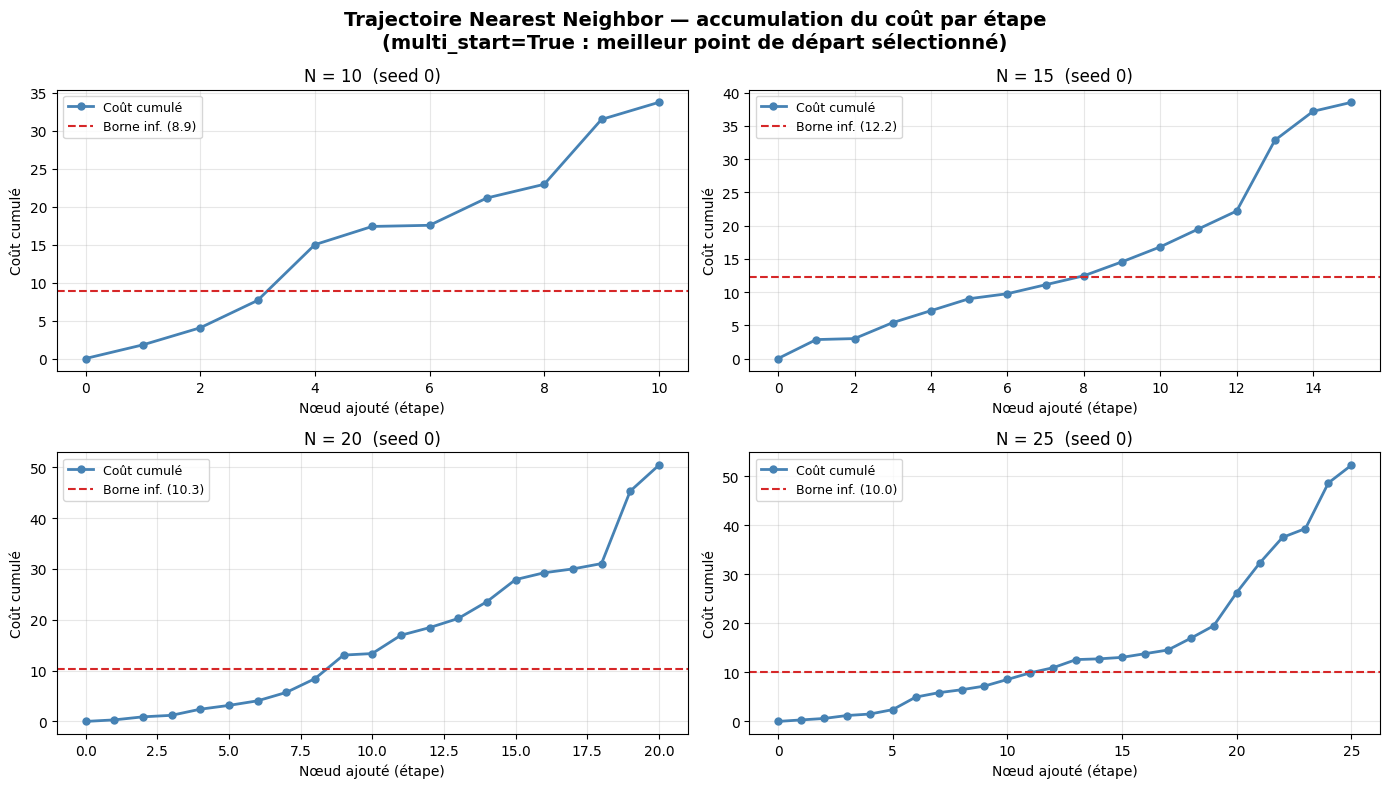

In [6]:
# ── Étude de trajectoire ──────────────────────────────────────────────────────
# On visualise l'accumulation du coût sur 4 tailles représentatives.
# Seed fixé à 0 pour la reproductibilité.
# En multi_start=True, on affiche la trajectoire du meilleur point de départ.

TRAJ_N_DISPLAY: list[int] = [10, 15, 20, 25]  # sous-ensemble de N_VALUES
TRAJ_SEED: int = 0

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, n in zip(axes, TRAJ_N_DISPLAY):
    seed, graph, ref = next(
        (s, g, r) for s, g, r in instances[n] if s == TRAJ_SEED
    )

    # multi_start=True : on cherche le meilleur point de départ
    best_history: list[float] = []
    best_cost_traj: float = float("inf")

    for start in graph.nodes():
        _, cost, history = _nearest_neighbor_tour_tracked(graph, start)
        if cost < best_cost_traj:
            best_cost_traj = cost
            best_history = history

    steps: list[int] = list(range(len(best_history)))
    labels: list[str] = ["Dépôt"] + [f"Étape {i}" for i in range(1, len(steps))]

    ax.plot(
        steps, best_history,
        marker="o", markersize=5, linewidth=2,
        color="steelblue", label="Coût cumulé"
    )
    ax.axhline(
        y=ref, color="#d62728", linestyle="--", linewidth=1.5,
        label=f"Borne inf. ({ref:.1f})"
    )
    ax.set_title(f"N = {n}  (seed {TRAJ_SEED})", fontsize=12)
    ax.set_xlabel("Nœud ajouté (étape)", fontsize=10)
    ax.set_ylabel("Coût cumulé", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "Trajectoire Nearest Neighbor — accumulation du coût par étape\n"
    "(multi_start=True : meilleur point de départ sélectionné)",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.show()

### Comparaison des trajectoires : mono-start vs multi-start

On compare pour une même instance la trajectoire du **meilleur** et du **pire** point de départ, afin d'illustrer la sensibilité de l'heuristique au choix du nœud initial.

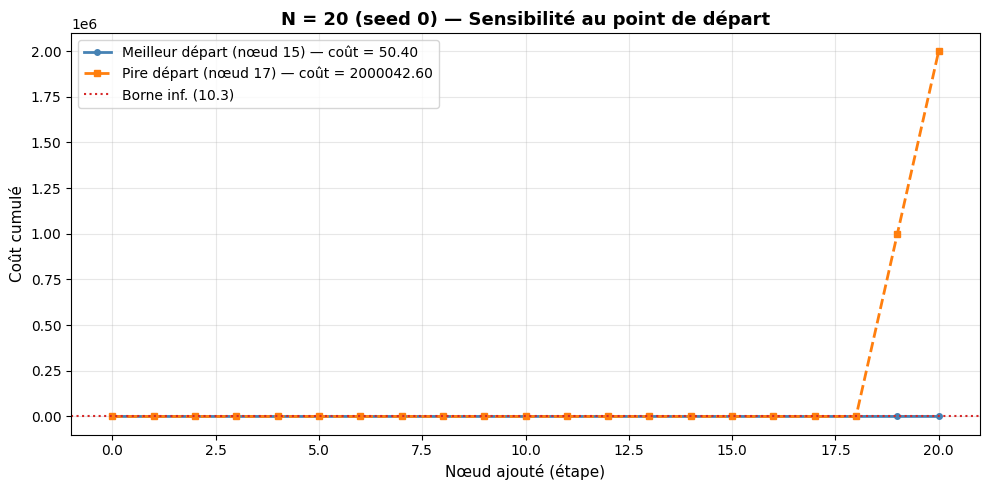

Écart meilleur/pire départ : 1999992.20 (3968238.5 %)


In [7]:
# ── Comparaison meilleur / pire point de départ ───────────────────────────────

COMP_N: int = 20
COMP_SEED: int = 0

_, graph_comp, ref_comp = next(
    (s, g, r) for s, g, r in instances[COMP_N] if s == COMP_SEED
)

all_results: list[tuple[int, float, list[float]]] = []
for start in graph_comp.nodes():
    _, cost, history = _nearest_neighbor_tour_tracked(graph_comp, start)
    all_results.append((start, cost, history))

all_results.sort(key=lambda x: x[1])
best_start, best_cost_comp, best_hist = all_results[0]
worst_start, worst_cost_comp, worst_hist = all_results[-1]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    range(len(best_hist)), best_hist,
    marker="o", markersize=4, linewidth=2,
    color="steelblue", label=f"Meilleur départ (nœud {best_start}) — coût = {best_cost_comp:.2f}"
)
ax.plot(
    range(len(worst_hist)), worst_hist,
    marker="s", markersize=4, linewidth=2,
    color="#ff7f0e", linestyle="--",
    label=f"Pire départ (nœud {worst_start}) — coût = {worst_cost_comp:.2f}"
)
ax.axhline(
    y=ref_comp, color="#d62728", linestyle=":", linewidth=1.5,
    label=f"Borne inf. ({ref_comp:.1f})"
)

ax.set_title(
    f"N = {COMP_N} (seed {COMP_SEED}) — Sensibilité au point de départ",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Nœud ajouté (étape)", fontsize=11)
ax.set_ylabel("Coût cumulé", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Écart meilleur/pire départ : {worst_cost_comp - best_cost_comp:.2f} "
      f"({100*(worst_cost_comp - best_cost_comp)/best_cost_comp:.1f} %)")

## Étude de l'influence des paramètres

Le paramètre principal de l'algorithme Nearest Neighbor est **`multi_start`** (booléen) :
- `False` : une seule exécution depuis un sommet aléatoire sans précédence (résultat potentiellement très variable selon la seed)
- `True`  : une exécution depuis **chaque sommet**, la meilleure tournée est conservée (déterministe à graphe fixé)

La **heatmap à double entrée** (style GitHub) ci-dessous présente :
- En **lignes** : les tailles de graphe $N \in \{10, 12, 15, 17, 20, 22, 25, 30\}$
- En **colonnes** : les valeurs de `multi_start` testées (`False` / `True`)
- La **couleur** code le gap moyen (%) — *plus clair = meilleur résultat (gap plus faible)*

In [8]:
# ── Calcul principal ──────────────────────────────────────────────────────────
# On fait varier `multi_start` et on enregistre les résultats pour chaque (N, multi_start).
#
# Note : en multi_start=False, l'algorithme tire un point de départ aléatoire.
# Pour obtenir des résultats stables, on répète NB_REPEAT fois et on prend la moyenne.
#
# Données stockées :
#   gap_matrix[n][ms]   = gap moyen (%) — pour la heatmap
#   cost_results[n][ms] = liste des coûts valides — pour les statistiques
#   gap_results[n][ms]  = liste des gaps (%) — pour les courbes

NB_REPEAT: int = 5  # répétitions en mode mono-start (multi_start=False) pour lisser l'aléa

gap_matrix: dict = {}
cost_results: dict = {}
gap_results: dict = {}

nb_total: int = len(N_VALUES) * len(MULTI_START_VALUES) * NB_SEEDS
print(
    f"Calcul en cours : {len(N_VALUES)} tailles × {len(MULTI_START_VALUES)} valeurs "
    f"× {NB_SEEDS} seeds = {nb_total} exécutions\n"
)

for n in N_VALUES:
    gap_matrix[n] = {}
    cost_results[n] = {}
    gap_results[n] = {}

    for ms in MULTI_START_VALUES:
        costs: list[float] = []
        gaps: list[float] = []

        for seed, graph, ref in instances[n]:
            if ms:
                # Déterministe à graphe fixé : une seule exécution suffit
                _, cost = resolve_by_nearest_neighbor(graph, multi_start=True)
                if cost < PENALTY_COST:
                    costs.append(cost)
                    gaps.append(compute_gap(cost, ref))
            else:
                # Aléatoire : on répète NB_REPEAT fois et on conserve le meilleur
                repeat_costs: list[float] = []
                for _ in range(NB_REPEAT):
                    _, cost = resolve_by_nearest_neighbor(graph, multi_start=False)
                    if cost < PENALTY_COST:
                        repeat_costs.append(cost)
                if repeat_costs:
                    best_repeat: float = min(repeat_costs)
                    costs.append(best_repeat)
                    gaps.append(compute_gap(best_repeat, ref))

        cost_results[n][ms] = costs
        gap_results[n][ms] = gaps
        gap_matrix[n][ms] = float(np.nanmean(gaps)) if gaps else float("nan")

    ms_summary = {ms: f"{gap_matrix[n][ms]:.1f}" for ms in MULTI_START_VALUES}
    print(f"  N={n:2d} : {ms_summary}")

print("\n✓ Calcul terminé.")

Calcul en cours : 8 tailles × 2 valeurs × 10 seeds = 160 exécutions

  N=10 : {False: '307.2', True: '297.0'}
  N=12 : {False: '408.7', True: '350.7'}
  N=15 : {False: '438.5', True: '357.0'}
  N=17 : {False: '431.5', True: '366.0'}
  N=20 : {False: '410.9', True: '373.7'}
  N=22 : {False: '505.4', True: '396.3'}
  N=25 : {False: '519.5', True: '432.8'}
  N=30 : {False: '478.2', True: '414.2'}

✓ Calcul terminé.


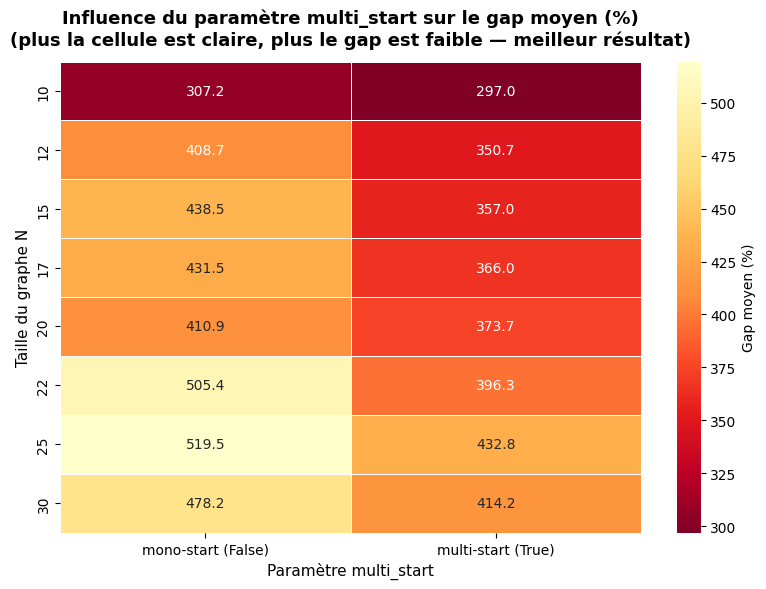

In [9]:
# ── Heatmap N × multi_start → gap moyen ───────────────────────────────────────

col_labels: dict[bool, str] = {False: "mono-start (False)", True: "multi-start (True)"}
heatmap_data: dict[str, dict[int, float]] = {
    col_labels[ms]: {n: gap_matrix[n][ms] for n in N_VALUES}
    for ms in MULTI_START_VALUES
}
heatmap_df = pd.DataFrame(heatmap_data, index=N_VALUES)
heatmap_df.index.name = "N"
heatmap_df.columns.name = "multi_start"

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd_r",           # plus clair = meilleur (gap plus faible)
    linewidths=0.6,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Gap moyen (%)"},
)

ax.set_title(
    "Influence du paramètre multi_start sur le gap moyen (%)\n"
    "(plus la cellule est claire, plus le gap est faible — meilleur résultat)",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel("Paramètre multi_start", fontsize=11)
ax.set_ylabel("Taille du graphe N", fontsize=11)
plt.tight_layout()
plt.show()

## Statistiques qualité des solutions

Pour `multi_start = True` (configuration par défaut), on calcule les **statistiques descriptives** sur l'ensemble des `NB_SEEDS` exécutions par taille de graphe $N$ :

| Indicateur | Description |
|---|---|
| Meilleur / Pire coût | Coût min/max obtenu sur toutes les seeds |
| Coût moyen / médian | Tendance centrale des coûts |
| Écart-type coût | Variabilité des coûts selon le graphe |
| Gap min / moyen / max / médian (%) | Distance relative à la borne inférieure |
| Écart-type gap (%) | Variabilité du gap |
| Taux de succès | Proportion d'instances où une tournée valide a été trouvée |

> **Note :** les données proviennent du calcul effectué dans la cellule *Calcul principal* ci-dessus.

In [10]:
# ── Statistiques pour multi_start = True ─────────────────────────────────────

stats_rows: list[dict] = []
MS_REF: bool = True  # paramètre de référence pour les stats

for n in N_VALUES:
    costs: list[float] = cost_results[n][MS_REF]
    gaps: list[float] = gap_results[n][MS_REF]

    if costs:
        stats_rows.append({
            "N":                    n,
            "Meilleur coût":        round(min(costs), 2),
            "Pire coût":            round(max(costs), 2),
            "Coût moyen":           round(float(np.mean(costs)), 2),
            "Coût médian":          round(float(np.median(costs)), 2),
            "Écart-type coût":      round(float(np.std(costs)), 2),
            "Gap min (%)":          round(min(gaps), 2),
            "Gap max (%)":          round(max(gaps), 2),
            "Gap moyen (%)":        round(float(np.mean(gaps)), 2),
            "Gap médian (%)":       round(float(np.median(gaps)), 2),
            "Écart-type gap (%)":   round(float(np.std(gaps)), 2),
            "Taux de succès":       f"{len(costs)}/{NB_SEEDS}",
        })
    else:
        stats_rows.append({"N": n, "Taux de succès": f"0/{NB_SEEDS}"})

df_stats = pd.DataFrame(stats_rows).set_index("N")

print(f"Statistiques des solutions — multi_start = {MS_REF}\n")
display(df_stats)

Statistiques des solutions — multi_start = True



,Meilleur coût,Pire coût,Coût moyen,Coût médian,Écart-type coût,Gap min (%),Gap max (%),Gap moyen (%),Gap médian (%),Écart-type gap (%),Taux de succès
N,,,,,,,,,,,
10,33.75,53.10,44.70,46.58,6.81,183.40,555.56,296.98,283.74,95.77,10/10
12,37.95,76.95,53.83,49.95,12.39,161.95,476.16,350.74,365.60,101.55,10/10
15,29.25,64.85,49.77,54.20,11.19,215.34,545.83,356.98,363.36,116.44,10/10
17,29.70,66.15,50.08,44.80,12.36,256.76,645.28,366.05,334.16,111.68,10/10
20,36.30,75.90,52.71,50.33,12.41,227.03,498.21,373.66,372.16,83.09,10/10
22,25.20,65.55,51.39,55.42,11.61,281.09,552.24,396.28,367.04,82.43,10/10
25,40.50,78.00,56.89,57.98,10.95,297.64,669.41,432.77,416.10,100.27,10/10
30,45.30,60.00,52.83,51.82,5.13,338.03,588.24,414.19,400.57,71.13,10/10


## Distance à la borne (gap)

Le **gap** mesure l'écart relatif entre la solution trouvée et la borne inférieure :

$$\text{gap} = 100 \times \frac{\text{coût} - \text{borne}}{\text{borne}} \quad (\%)$$

- Un **gap proche de 0 %** indique que l'algorithme s'approche de l'optimal théorique.
- On compare les deux configurations (`multi_start=True` vs `multi_start=False`) pour chaque taille $N$.
- La **zone ombrée** représente l'écart-type entre les `NB_SEEDS` seeds (variabilité).

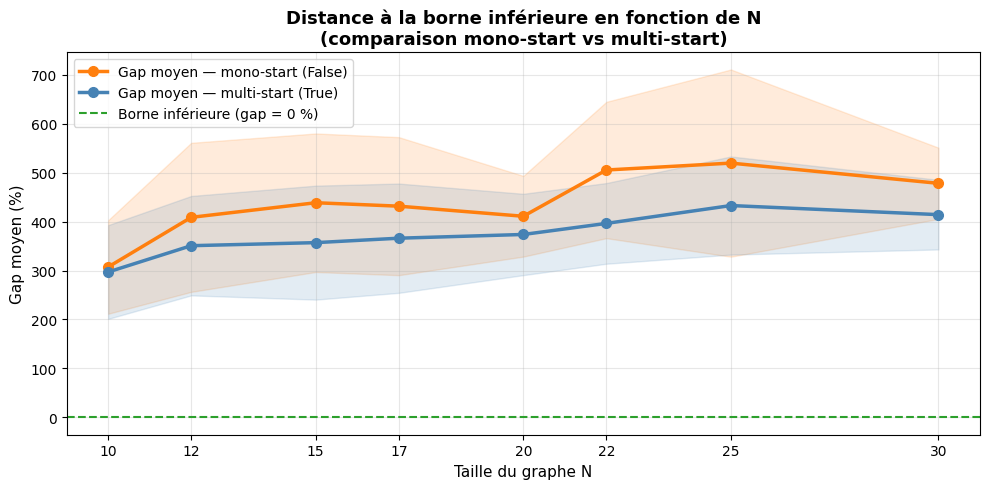

In [11]:
# ── Courbe gap moyen ± écart-type en fonction de N — comparaison multi_start ──

colors: dict[bool, str] = {True: "steelblue", False: "#ff7f0e"}
labels_ms: dict[bool, str] = {True: "multi-start (True)", False: "mono-start (False)"}

fig, ax = plt.subplots(figsize=(10, 5))

for ms in MULTI_START_VALUES:
    gap_means_arr = np.array([
        float(np.mean(gap_results[n][ms])) if gap_results[n][ms] else float("nan")
        for n in N_VALUES
    ])
    gap_stds_arr = np.array([
        float(np.std(gap_results[n][ms])) if gap_results[n][ms] else float("nan")
        for n in N_VALUES
    ])

    ax.plot(
        N_VALUES, gap_means_arr,
        "o-", linewidth=2.5, markersize=7,
        color=colors[ms], label=f"Gap moyen — {labels_ms[ms]}"
    )
    ax.fill_between(
        N_VALUES,
        np.clip(gap_means_arr - gap_stds_arr, 0, None),
        gap_means_arr + gap_stds_arr,
        alpha=0.15, color=colors[ms]
    )

ax.axhline(
    y=0, color="#2ca02c", linestyle="--", linewidth=1.5,
    label="Borne inférieure (gap = 0 %)"
)

ax.set_title(
    "Distance à la borne inférieure en fonction de N\n"
    "(comparaison mono-start vs multi-start)",
    fontsize=13, fontweight="bold",
)
ax.set_xlabel("Taille du graphe N", fontsize=11)
ax.set_ylabel("Gap moyen (%)", fontsize=11)
ax.set_xticks(N_VALUES)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Définition des paramètres optimisés

On identifie la valeur de `multi_start` qui **minimise le gap moyen global** (moyenné sur toutes les tailles de graphe $N$ et toutes les seeds).

Le barplot ci-dessous synthétise les résultats de l'étude paramétrique :
- La barre **rouge** correspond à la configuration optimale.
- `multi_start=True` explore exhaustivement tous les sommets de départ, ce qui améliore systématiquement la qualité au prix d'un temps de calcul proportionnel à $N$.

  RÉSULTATS — Nearest Neighbor

  Gap moyen global par configuration :

    multi_start = False  →  gap moyen = 437.48 %
    multi_start = True   →  gap moyen = 373.46 %  ◄ OPTIMAL

  ────────────────────────────────────────────────
  Meilleur paramètre : multi_start = True
  Gap moyen obtenu   : 373.46 %


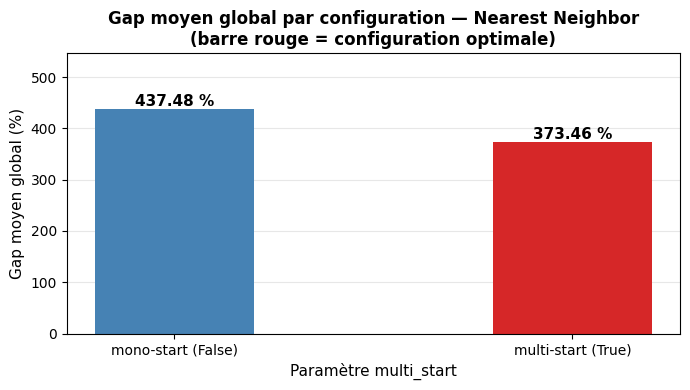

In [12]:
# ── Meilleurs paramètres ──────────────────────────────────────────────────────
# Critère : minimiser le gap moyen global (moyenne sur tous les N et toutes les seeds)

global_gap_by_ms: dict[bool, float] = {}
for ms in MULTI_START_VALUES:
    all_gaps: list[float] = []
    for n in N_VALUES:
        all_gaps.extend(gap_results[n][ms])
    global_gap_by_ms[ms] = float(np.nanmean(all_gaps)) if all_gaps else float("nan")

best_ms: bool = min(global_gap_by_ms, key=lambda k: global_gap_by_ms[k])
best_gap: float = global_gap_by_ms[best_ms]

print("=" * 62)
print("  RÉSULTATS — Nearest Neighbor")
print("=" * 62)
print(f"\n  Gap moyen global par configuration :\n")
for ms in MULTI_START_VALUES:
    arrow = "  ◄ OPTIMAL" if ms == best_ms else ""
    print(f"    multi_start = {str(ms):5s}  →  gap moyen = {global_gap_by_ms[ms]:6.2f} %{arrow}")

print(f"\n  {'─' * 48}")
print(f"  Meilleur paramètre : multi_start = {best_ms}")
print(f"  Gap moyen obtenu   : {best_gap:.2f} %")
print("=" * 62)

# ── Barplot récapitulatif ─────────────────────────────────────────────────────
ms_sorted = sorted(global_gap_by_ms.keys())
gaps_sorted = [global_gap_by_ms[ms] for ms in ms_sorted]
bar_colors = ["#d62728" if ms == best_ms else "steelblue" for ms in ms_sorted]
bar_labels = [labels_ms[ms] for ms in ms_sorted]

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(bar_labels, gaps_sorted, color=bar_colors, width=0.4, zorder=2)

for bar, gap_val in zip(bars, gaps_sorted):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{gap_val:.2f} %",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_title(
    "Gap moyen global par configuration — Nearest Neighbor\n"
    "(barre rouge = configuration optimale)",
    fontsize=12, fontweight="bold"
)
ax.set_ylabel("Gap moyen global (%)", fontsize=11)
ax.set_xlabel("Paramètre multi_start", fontsize=11)
ax.grid(axis="y", alpha=0.3, zorder=1)
ax.set_ylim(0, max(gaps_sorted) * 1.25)
plt.tight_layout()
plt.show()